In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier, Pool
from imblearn.over_sampling import SMOTE
import shap
from shap import TreeExplainer
import optuna

Обозначение признаков:

SeriousDlqin2yrs - Лицо, совершившее просрочку платежа на 90 дней или что-то похуже

RevolvingUtilizationOfUnsecuredLines - Общий остаток средств на кредитных картах и личных кредитных линиях, за исключением операций с недвижимостью и без рассрочки платежа

NumberOfTime30-59DaysPastDueNotWorse - Несколько раз заемщик просрочивал платеж на 30-59 дней, но за последние 2 года ситуация не ухудшилась.

DebtRatio - Ежемесячные выплаты по долгам, алиментам, расходы на проживание, разделенные на ежемесячный валовой доход

MonthlyIncome - Доход ежемесячный

NumberOfOpenCreditLinesAndLoans - Количество открытых кредитов (например, автокредит в рассрочку или ипотека) и кредитных линий (например, кредитные карты)

NumberOfTimes90DaysLate - Количество случаев, когда заемщик просрочивал платеж на 90 дней и более.

NumberRealEstateLoansOrLines - Количество ипотечных кредитов и займов на недвижимость, включая кредитные линии на приобретение жилья

NumberOfTime60-89DaysPastDueNotWorse - Несколько раз заемщик просрочивал платеж на 60-89 дней, но за последние 2 года ситуация не ухудшилась.

NumberOfDependents - Количество иждивенцев в семье, не считая их самих (супруг(а), дети и т.д.)

In [ ]:
df = pd.read_csv('cs-training.csv')
df

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [ ]:
df = df.drop('Unnamed: 0', axis=1)
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [ ]:
print(f"Доля класса 1: {len(df[df['SeriousDlqin2yrs'] == 1])/ len(df)}")
print(f"Доля класса 0: {len(df[df['SeriousDlqin2yrs'] == 0])/ len(df)}")

Доля класса 1: 0.06684
Доля класса 0: 0.93316


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

In [ ]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


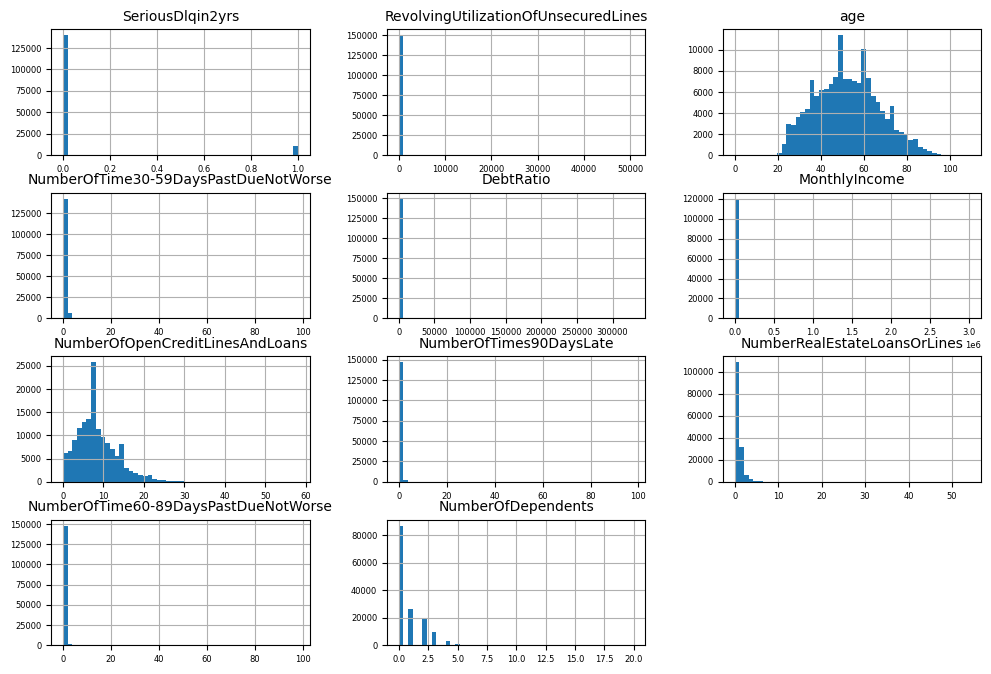

In [ ]:
plt.rc('font',size=10)
plt.rc('axes',labelsize=10,titlesize=10)
plt.rc('legend',fontsize=8)
plt.rc('xtick',labelsize=6)
plt.rc('ytick',labelsize=6)

df.hist(bins=50,figsize=(12,8))
plt.show()

Просмотрим корееляцию между признаками:

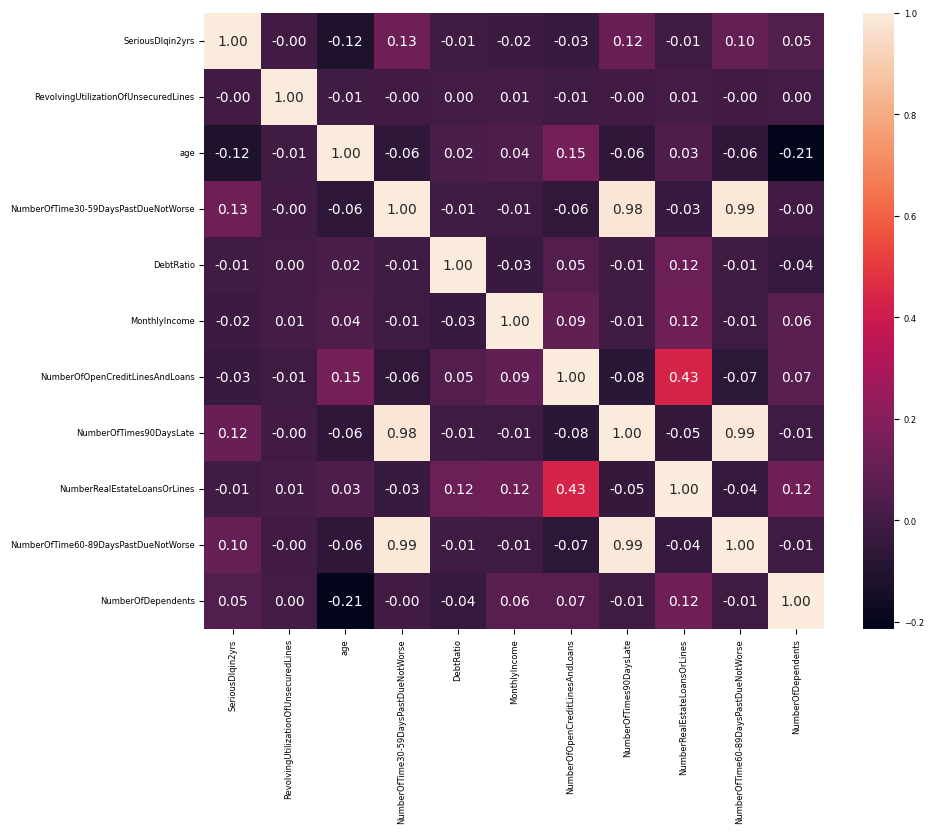

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.show()

Как видно, 3 признака имеют мультиколлинеарность друг с другом. Так как данные имеют схожий смысл, то стоит удалить такой признак как NumberOfTime60-89DaysPastDueNotWorse, потому что:

Просрочки 60–89 дней — промежуточная категория. Они менее распространены, чем 30–59 дней, и менее критичны, чем 90+ дней.

NumberOfTimes90DaysLate (90+ дней) имеет более сильную связь с SeriousDlqin2yrs, так как тяжёлые просрочки чаще приводят к дефолту.

NumberOfTime30-59DaysPastDueNotWorse встречается чаще и может лучше отражать ранние признаки финансовых проблем.

In [ ]:
df.drop('NumberOfTime60-89DaysPastDueNotWorse', axis = 1)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0.0
...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0.0
149996,0,0.299745,44,0,0.716562,5584.0,4,0,1,2.0
149997,0,0.246044,58,0,3870.000000,NaN,18,0,1,0.0
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0.0


По каждлому признаку можно сделать выоводы:

Значения признака возраста имеет диапазон от 0 до 109, что является подозрительным, так как по законодательству кредиты выдаются с 18 летия.
Скорее всего имеются анамальные заничения

Зачения признака DebtRatio имеет диапозон от 0 до 329664.
Скорее всего имеются анамльные значнеия

Значения признака доля использованного кредитного лимита как правило должен варьироваться в даипазаоне 0 до 1, соответсвено, числа, которые выше 1 могут означать слежующее:

1)Заемщик привысил кредитный лимит (штрафы, проценты или допольнительные сборы увеличили долг)
2)Ошибки в данных

Зачения признака MonthlyIncome имеет диапозон от 0 до 3008750
Что подсказывает на то, что также имюется анамальные значения

В признаке кол-во открытых кредитов также имеются анамальные значения

В признаке NumberRealEstateLoansOrLines присутствуют анамальные значения

В признаке NumberOfDependents присутствуют анамальные значения






Изначально проведем анализ признака age:

In [ ]:
df[df['age'] < 18]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


In [ ]:

len(df[df['age'] > 100])

13

Можно обратить внимание, что только один объект имеет возраст < 18, соответсвтенно, размер выборке позволяет произвести удаление данного объекта

Также 13 объектоа имеют возраст > 100 лет, что тоже является аномалией.

In [ ]:
df = df[(df['age']>18) & (df['age']<100)]
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
print(f"Количество записей с возрастом > 90: {len(df[df['age'] > 90])}")
print(f"Доля записей с возрастом > 90: {(df['age'] > 90).mean() * 100:.2f}%")

Количество записей с возрастом > 90: 476
Доля записей с возрастом > 90: 0.32%


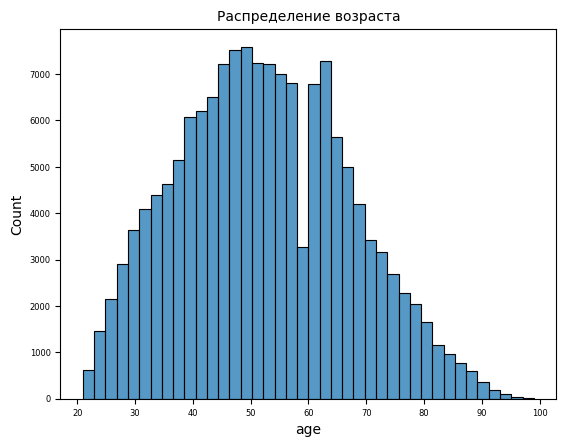

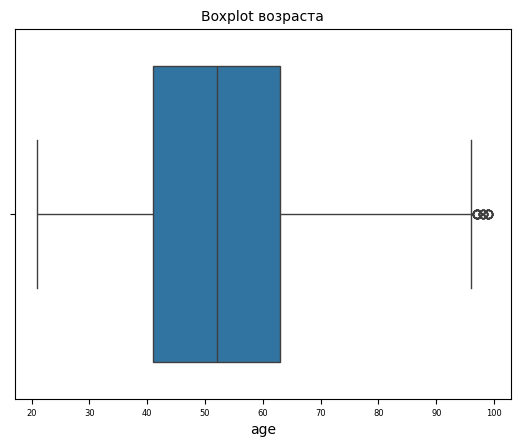

In [ ]:
sns.histplot(df['age'], bins=40)
plt.title("Распределение возраста")
plt.show()
sns.boxplot(x=df['age'])
plt.title("Boxplot возраста")
plt.show()

Пик на 90–91 годах: 352 записи из 674 (52%) сосредоточены на возрастах 90 и 91. Это неестественно и указывает на систематическую ошибку (например, возраст 90–91 как заглушка для пропущенных данных или ошибка).
Низкая утилизация и просрочки: Медиана RevolvingUtilizationOfUnsecuredLines (1.6%), отсутствие просрочек (медиана 0 для обоих признаков) и низкий дефолт (2%) делают эти записи аномальными. Реальные заёмщики, даже пожилые, обычно имеют более разнообразные показатели утилизации и просрочек.

In [ ]:
median_age = df[df['age'] < 90]['age'].median()
df.loc[df['age'] >= 90, 'age'] = median_age

Рассмотрим признак NumberOfTime30-59DaysPastDueNotWorse

In [ ]:
df['NumberOfTime30-59DaysPastDueNotWorse'].value_counts()

NumberOfTime30-59DaysPastDueNotWorse
0     126006
1      16032
2       4597
3       1754
4        747
5        342
98       264
6        140
7         54
8         25
9         12
96         5
10         4
12         2
13         1
11         1
Name: count, dtype: int64

Как видно, в данном признаке проистутсвуют аномалии в виде 98,96. Такие числа не могут быть в реальной жизни, соответсвено, это скорее всего ошибка


In [ ]:
df[df['NumberOfTime30-59DaysPastDueNotWorse'] >= 96]['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
1    147
0    122
Name: count, dtype: int64

Видно, что потери даваольно некритичны, значит можно убрать данные объекты

In [ ]:
df = df[df['NumberOfTime30-59DaysPastDueNotWorse'] < 96]

Также стоит обратить внимание на подобный признак: NumberOfTimes90DaysLate

In [ ]:
df['NumberOfTimes90DaysLate'].value_counts()

NumberOfTimes90DaysLate
0     141648
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
13         4
15         2
14         2
12         2
17         1
Name: count, dtype: int64

Данные вполне правдоподобные, поэтому оставляем как есть

DebtRatio - финансовый показатель,показывающая какую часть дохода заемщик тратит на обслуживание долгов, данный показатель варьируется от 0 до 1.

Некоторые признаки превышают 1, на то могут быть ряд причин:

1)Доход нулевой, либо очень низкий

2)В колонке дохода есть пропуски, поэтому болльшие числа - сумма долгов, а не доля


In [ ]:
print(df[df['DebtRatio'] > 1]['MonthlyIncome'].isna().sum())
print('-'* 50)
print(df[df['DebtRatio'] > 1]['MonthlyIncome'].value_counts())

27870
--------------------------------------------------
MonthlyIncome
0.0       1521
1.0        557
2500.0     169
2000.0     143
3000.0     116
          ... 
2751.0       1
3895.0       1
3087.0       1
531.0        1
9125.0       1
Name: count, Length: 1896, dtype: int64


Видно, что проблема заключаласт в пропусках признака "ежемесячный доход"


DebtRatio = Ежемесячные обязательства \ Ежемесячный валовой доход, соответсвтенно, можно найти Ежемесячные обязательства у объектов, которые не имеют аномалии а данном признаке. Следовательно, Ежемесячные обязательства = DebtRatio * Ежемесячный валовой доход. Это нужно для того, чтобы определить корректно DTI для признаков, которые имеют аномальные значения данного признака, по след причинам: 0 доход, пустоты в доходах. Признак доход для таких объектов мы заменили на медиану по возврастной категории, также и поступим и с признаком  Ежемесячные обязательства, и когда мы получим эти данные, то можно для таких объектов корректно расчитать DTI.

In [ ]:
def  remake_monthincome(row: pd.Series) -> float:
    """
    Выполняет импьютацию пропущенных значений в столбце 'MonthlyIncome' на основе среднего
    дохода заёмщиков в возрастном диапазоне ±3 года от текущего возраста строки.
    Если значение 'MonthlyIncome' не пропущено, возвращается исходное значение.

    Аргументы:
        row (pd.Series): Одна строка DataFrame, содержащая все признаки, включая
                        'MonthlyIncome' и 'age'.

    Возвращаемое значение:
        float: Среднее значение дохода для возрастного диапазона, если 'MonthlyIncome'
               является NaN, иначе исходное значение 'MonthlyIncome'.
    """
    if pd.isnull(row['MonthlyIncome']):
        avg_income = df[(df['age'] >= row['age'] - 3) & (df['age'] <= row['age'] + 3)]['MonthlyIncome'].mean()
        return avg_income
    else:
        return row['MonthlyIncome']



def remake_monthly_debt_payments(row: pd.Series) -> float:
    """
    Выполняет импьютацию пропущенных значений в столбце 'MonthlyDebtPayments' на основе
    среднего значения ежемесячных платежей заёмщиков в возрастном диапазоне ±3 года
    от текущего возраста строки. Если значение 'MonthlyDebtPayments' не пропущено,
    возвращается исходное значение.

    Аргументы:
        row (pd.Series): Одна строка DataFrame, содержащая все признаки, включая
                        'MonthlyDebtPayments' и 'age'.

    Возвращаемое значение:
        float: Среднее значение ежемесячных платежей для возрастного диапазона, если
               'MonthlyDebtPayments' является NaN, иначе исходное значение 'MonthlyDebtPayments'.
    """
    if pd.isnull(row['MonthlyDebtPayments']):
        avg_debt = df[(df['age'] >= row['age'] - 3) & (df['age'] <= row['age'] + 3)]['MonthlyDebtPayments'].mean()
        return avg_debt
    else:
        return row['MonthlyDebtPayments']

# Применение функции к столбцу 'ежемесячный доход'
df['MonthlyIncome'] = df.apply(remake_monthincome, axis=1)

df['MonthlyDebtPayments'] = np.where(
    (df['DebtRatio'] <= 1) & (df['MonthlyIncome'] > 1),
    df['DebtRatio'] * df['MonthlyIncome'],
    np.nan
)

# Заполнение MonthlyDebtPayments для аномалий/пропусков
df['MonthlyDebtPayments'] = df.apply(remake_monthly_debt_payments, axis=1)

# Заполнение оставшихся пропусков (если есть редкие возрасты)
df['MonthlyDebtPayments'] = df['MonthlyDebtPayments'].fillna(df['MonthlyDebtPayments'].median())

# Шаг 3: Пересчёт DebtRatio
df = df[df['DebtRatio'] <= 1]

df.isna().sum()

SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                             0
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      449
MonthlyDebtPayments                       0
dtype: int64

Нужно решить проблему с пропусками и аномалиями в признаке 'NumberOfDependents', для начала стоит обратить внимание на аномалии, которые находятся в этом признаке. Стоит обратить внимание на объекты, которые имеют больше 10 еждивенцев:

In [ ]:
df[df['NumberOfDependents'] >= 10]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyDebtPayments
6299,0,0.226616,40,1,0.576539,6316.0,11,2,1,0,20.0,3641.423463
10618,0,0.000000,44,0,0.035590,12896.0,5,0,0,0,10.0,458.964410
12982,0,0.325828,39,0,0.027100,4833.0,6,0,0,0,10.0,130.972898
39095,0,0.079194,60,0,0.133582,7500.0,10,0,0,0,10.0,1001.866417
123911,0,0.017858,47,1,0.368932,9166.0,7,0,1,0,10.0,3381.631069
128034,0,1.000000,53,1,0.230054,3333.0,3,1,1,0,13.0,766.769945


Предположительно, присутствовали ошибки при вводе данных, напривем человек имеет 2 еждивенцев, однако по ошибке ввел 20. Также с 10

In [ ]:
df['NumberOfDependents'] = df['NumberOfDependents'].replace({10: 1, 20: 2})

C:\Users\User\AppData\Local\Temp\ipykernel_8180\1254898256.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['NumberOfDependents'] = df['NumberOfDependents'].replace({10: 1, 20: 2})


In [ ]:
df['NumberOfDependents'].value_counts()

NumberOfDependents
0.0     62300
1.0     23298
2.0     16952
3.0      8223
4.0      2527
5.0       652
6.0       141
7.0        46
8.0        22
9.0         4
13.0        1
Name: count, dtype: int64

In [ ]:
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].mode()[0]).astype(int)

C:\Users\User\AppData\Local\Temp\ipykernel_8180\2114276801.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].mode()[0]).astype(int)


Рассмотрим признак Monthlyincome

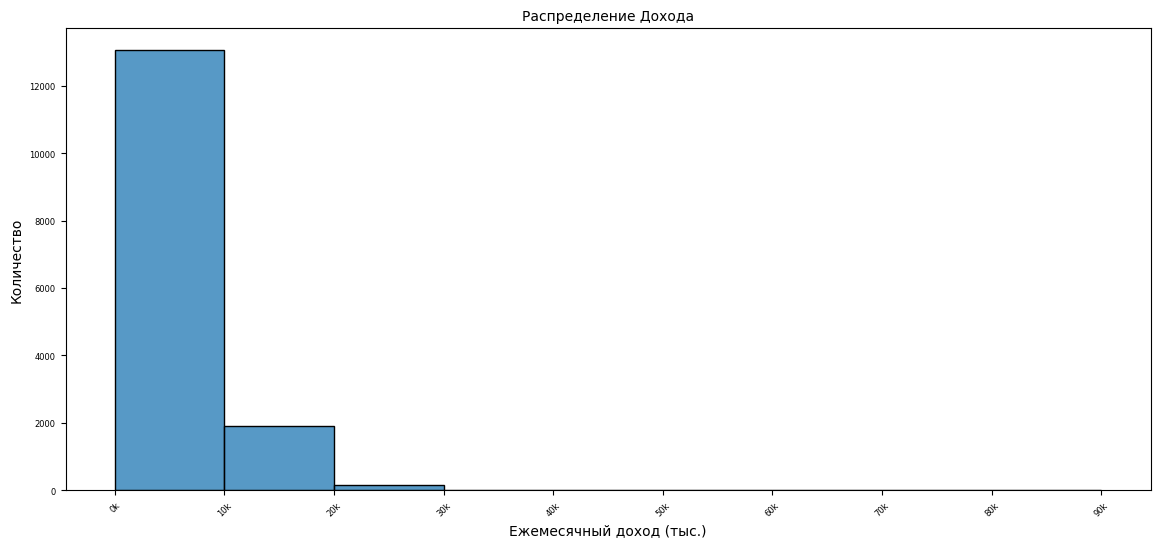

In [ ]:
plt.figure(figsize=(14, 6))


bins = [0, 10000, 20000, 30000, 40000,50000, 60000, 70000, 80000, 90000]
sns.histplot(df['MonthlyIncome'], bins=bins)
plt.xticks(bins, [f'{int(b/1000)}k' for b in bins], rotation=45)
plt.title("Распределение Дохода")
plt.xlabel("Ежемесячный доход (тыс.)")
plt.ylabel("Количество")
plt.show()


Данные скошены, поэтому оптимальных решением (во избежании потери множества значений) для верхней границы можно взять множитель 3

In [ ]:
Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
high_bound = Q3 + 3 * IQR
print(f'Нижняя граница: {lower_bound}')
print(f"Вверхняя граница: {high_bound}")

Нижняя граница: -3355.5
Вверхняя граница: 22390.0


In [ ]:
df = df[df['MonthlyIncome'] <= 30000]

In [ ]:
df['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    106259
1      7568
Name: count, dtype: int64

RevolvingUtilizationOfUnsecuredLines - Общий остаток средств на кредитных картах и личных кредитных линиях, за исключением операций с недвижимостью и без рассрочки платежа

In [ ]:
df[df['RevolvingUtilizationOfUnsecuredLines'] > 1000]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyDebtPayments
293,0,2340.0,45,0,0.339333,8333.0,7,0,2,0,2,2827.660664
697,1,2066.0,58,0,0.271121,6000.0,8,1,1,0,1,1626.728880
1991,1,1143.0,44,2,0.547762,6500.0,13,0,4,0,2,3560.452239
2331,0,6324.0,59,0,0.136673,11318.0,4,0,1,0,1,1546.863328
4278,0,1982.0,33,0,0.144982,8000.0,4,0,0,0,0,1159.855016
...,...,...,...,...,...,...,...,...,...,...,...,...
143678,0,4881.0,47,0,0.203452,18018.0,5,0,3,0,3,3665.796550
144683,0,1761.0,64,0,0.082235,7587.0,2,0,1,0,0,623.917764
145587,0,7452.0,52,0,0.351365,10000.0,5,0,2,0,3,3513.648640
149102,0,6109.0,43,0,0.229902,12500.0,9,0,2,0,0,2873.770100


In [ ]:
df = df[df['RevolvingUtilizationOfUnsecuredLines'] < 20000]
df = df[df['NumberRealEstateLoansOrLines']<20]

Решение проблемы с дисбалансом:

In [ ]:
def balance(df: pd.DataFrame)-> pd.DataFrame:
    """
    Выполняет балансировку набора данных по целевой переменной 'SeriousDlqin2yrs',
    уравнивая количество примеров положительного класса (1) и отрицательного класса (0).
    Отрицательный класс (0) случайным образом подбирается до количества, равного числу
    примеров положительного класса (1), с сохранением порядка.

    Аргументы:
        df (pd.DataFrame): Исходный DataFrame, содержащий столбец 'SeriousDlqin2yrs'
                          с целевой переменной (0 или 1).

    Возвращаемое значение:
        pd.DataFrame: Сбалансированный DataFrame, где количество строк с 'SeriousDlqin2yrs == 1'
                      равно количеству строк с 'SeriousDlqin2yrs == 0', с перемешанными
                      строками и сброшенными индексами.
    """
    num = df['SeriousDlqin2yrs'].value_counts()[1]
    df_t = df[df.SeriousDlqin2yrs==1]
    df_f = df[df.SeriousDlqin2yrs==0].sample(frac=1,random_state=21)[0:num]
    df = pd.concat([df_t,df_f]).sample(frac=1).reset_index(drop=True)

    return df

In [ ]:
df = balance(df)

In [ ]:
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=21)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.8, random_state=21)
cv = StratifiedKFold(n_splits=5,shuffle=True)

Используем optuna для подбора гиперпараметров

In [ ]:
def objective(trial: optuna.trial.Trial) -> float:
    """
    Определяет целевую функцию для оптимизации гиперпараметров модели CatBoost с использованием
    Optuna. Функция настраивает параметры модели, обучает её на тренировочных данных и
    возвращает значение метрики precision_score на валидационной выборке.

    Аргументы:
        trial (optuna.trial.Trial): Объект Optuna для предложения значений гиперпараметров.

    Возвращаемое значение:
        float: Значение метрики precision_score на валидационной выборке для оценки качества
               модели с заданными гиперпараметрами.
    """
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1500),
        'depth': trial.suggest_int('depth', 4, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 25),
        'random_seed': 42,
        'verbose': 0
    }
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=100)
    y_pred = model.predict(X_val)
    return precision_score(y_val, y_pred)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
best_params = study.best_params
print('Best params:', best_params)

[I 2025-08-13 13:31:27,452] A new study created in memory with name: no-name-222b0cdd-f285-4f76-890c-1efc0dabce81



8. Training CatBoost with Optuna (Class Weighting via scale_pos_weight)
0:	learn: 0.5176871	test: 0.5189828	best: 0.5189828 (0)	total: 143ms	remaining: 2m 17s
100:	learn: 0.1681354	test: 0.1970599	best: 0.1919205 (54)	total: 536ms	remaining: 4.56s
200:	learn: 0.1472647	test: 0.2145968	best: 0.1919205 (54)	total: 808ms	remaining: 3.05s
300:	learn: 0.1308233	test: 0.2344734	best: 0.1919205 (54)	total: 1.13s	remaining: 2.47s
400:	learn: 0.1213566	test: 0.2490638	best: 0.1919205 (54)	total: 1.42s	remaining: 1.99s
500:	learn: 0.1132041	test: 0.2644162	best: 0.1919205 (54)	total: 1.79s	remaining: 1.64s
600:	learn: 0.1060827	test: 0.2779396	best: 0.1919205 (54)	total: 2.15s	remaining: 1.29s
700:	learn: 0.0996233	test: 0.2901586	best: 0.1919205 (54)	total: 2.48s	remaining: 921ms
800:	learn: 0.0939015	test: 0.3020518	best: 0.1919205 (54)	total: 2.84s	remaining: 567ms
900:	learn: 0.0899759	test: 0.3124080	best: 0.1919205 (54)	total: 3.16s	remaining: 210ms


[I 2025-08-13 13:31:31,063] Trial 0 finished with value: 0.518355043599957 and parameters: {'iterations': 961, 'depth': 4, 'learning_rate': 0.15227399251156215, 'l2_leaf_reg': 3.829569788589037, 'scale_pos_weight': 13.548185285783294}. Best is trial 0 with value: 0.518355043599957.


960:	learn: 0.0877530	test: 0.3177285	best: 0.1919205 (54)	total: 3.37s	remaining: 0us

bestTest = 0.1919205021
bestIteration = 54

Shrink model to first 55 iterations.
0:	learn: 0.5055551	test: 0.5071747	best: 0.5071747 (0)	total: 7.76ms	remaining: 2.68s
100:	learn: 0.1324629	test: 0.1752778	best: 0.1614895 (31)	total: 759ms	remaining: 1.85s
200:	learn: 0.1107238	test: 0.2111213	best: 0.1614895 (31)	total: 1.35s	remaining: 978ms


[I 2025-08-13 13:31:33,129] Trial 1 finished with value: 0.5001034982405299 and parameters: {'iterations': 347, 'depth': 5, 'learning_rate': 0.14504608320827495, 'l2_leaf_reg': 1.4341264859936864, 'scale_pos_weight': 17.957356983534066}. Best is trial 0 with value: 0.518355043599957.


...

0:	learn: 0.4937461	test: 0.4948534	best: 0.4948534 (0)	total: 9.96ms	remaining: 8.39s
100:	learn: 0.1674364	test: 0.3279023	best: 0.2846419 (17)	total: 797ms	remaining: 5.86s
200:	learn: 0.1091019	test: 0.3878521	best: 0.2846419 (17)	total: 1.65s	remaining: 5.26s
300:	learn: 0.0839178	test: 0.4205575	best: 0.2846419 (17)	total: 2.28s	remaining: 4.11s
400:	learn: 0.0672510	test: 0.4502385	best: 0.2846419 (17)	total: 3.1s	remaining: 3.41s
500:	learn: 0.0532181	test: 0.4778586	best: 0.2846419 (17)	total: 3.79s	remaining: 2.59s
600:	learn: 0.0441753	test: 0.4932016	best: 0.2846419 (17)	total: 4.47s	remaining: 1.8s
700:	learn: 0.0377048	test: 0.5104137	best: 0.2846419 (17)	total: 5.15s	remaining: 1.04s
800:	learn: 0.0316428	test: 0.5269908	best: 0.2846419 (17)	total: 5.84s	remaining: 306ms


[I 2025-08-13 13:36:46,691] Trial 48 finished with value: 0.5824819337154249 and parameters: {'iterations': 843, 'depth': 7, 'learning_rate': 0.26613986229531605, 'l2_leaf_reg': 6.685842552947977, 'scale_pos_weight': 6.912557879648084}. Best is trial 45 with value: 0.779468495499357.


842:	learn: 0.0306160	test: 0.5303757	best: 0.2846419 (17)	total: 6.16s	remaining: 0us

bestTest = 0.2846419406
bestIteration = 17

Shrink model to first 18 iterations.
0:	learn: 0.4921983	test: 0.4940476	best: 0.4940476 (0)	total: 7.56ms	remaining: 8.95s
100:	learn: 0.1612489	test: 0.2593855	best: 0.2304476 (25)	total: 672ms	remaining: 7.21s
200:	learn: 0.1223536	test: 0.3022373	best: 0.2304476 (25)	total: 1.37s	remaining: 6.73s
300:	learn: 0.0992614	test: 0.3352201	best: 0.2304476 (25)	total: 1.97s	remaining: 5.78s
400:	learn: 0.0818009	test: 0.3613817	best: 0.2304476 (25)	total: 2.49s	remaining: 4.87s
500:	learn: 0.0686622	test: 0.3872616	best: 0.2304476 (25)	total: 3.24s	remaining: 4.42s
600:	learn: 0.0607307	test: 0.4049460	best: 0.2304476 (25)	total: 3.9s	remaining: 3.79s
700:	learn: 0.0526114	test: 0.4257825	best: 0.2304476 (25)	total: 4.52s	remaining: 3.12s
800:	learn: 0.0460814	test: 0.4437276	best: 0.2304476 (25)	total: 5.04s	remaining: 2.42s
900:	learn: 0.0421406	test: 0.455

[I 2025-08-13 13:36:54,222] Trial 49 finished with value: 0.5408591182137595 and parameters: {'iterations': 1185, 'depth': 6, 'learning_rate': 0.21137588425060594, 'l2_leaf_reg': 4.374634795557121, 'scale_pos_weight': 10.153984403673064}. Best is trial 45 with value: 0.779468495499357.


1184:	learn: 0.0335439	test: 0.4829493	best: 0.2304476 (25)	total: 7.11s	remaining: 0us

bestTest = 0.2304476169
bestIteration = 25

Shrink model to first 26 iterations.
Best params: {'iterations': 1434, 'depth': 6, 'learning_rate': 0.23655668768052823, 'l2_leaf_reg': 7.103309292314185, 'scale_pos_weight': 1.0070989823764136}


In [ ]:
model = CatBoostClassifier(**best_params, verbose=200)
model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)

print("\n9. Evaluating Model")
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print('Test Metrics:')
print(f'AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred):.4f}')
print(f'F1: {f1_score(y_test, y_pred):.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred))

0:	learn: 0.6095523	test: 0.6149497	best: 0.6149497 (0)	total: 6.21ms	remaining: 8.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.482511994
bestIteration = 27

Shrink model to first 28 iterations.

9. Evaluating Model
Test Metrics:
AUC-ROC: 0.8449
Precision: 0.7895
Recall: 0.7445
F1: 0.7664

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.79      0.77      1485
           1       0.79      0.74      0.77      1542

    accuracy                           0.77      3027
   macro avg       0.77      0.77      0.77      3027
weighted avg       0.77      0.77      0.77      3027



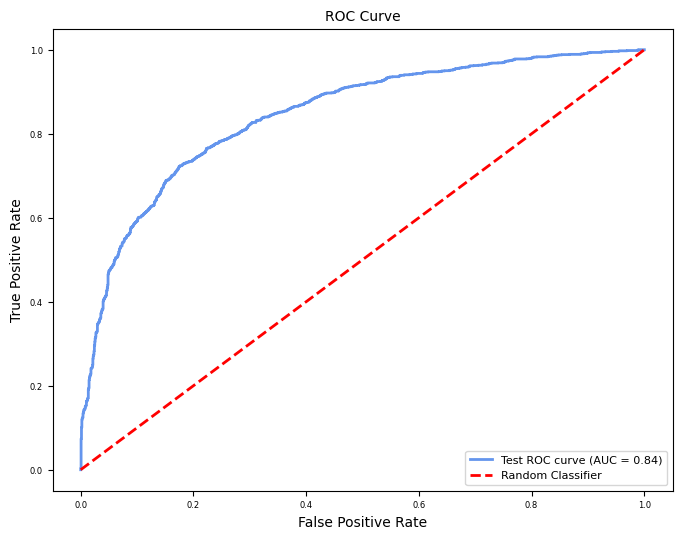

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_proba)
roc_auc_test = auc(fpr_test, tpr_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, color='cornflowerblue', lw=2, label='Test ROC curve (AUC = {:.2f})'.format(roc_auc_test))
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
print("Кросс-валидация")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
    print(f'\nFold {fold}')

    X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
    y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]


    train_pool = Pool(X_fold_train, y_fold_train)
    val_pool = Pool(X_fold_val, y_fold_val)


    model_cv = CatBoostClassifier(**best_params, verbose=0)
    model_cv.fit(train_pool, eval_set=val_pool, early_stopping_rounds=100)

    # Предсказываем и оцениваем
    y_pred_fold = model_cv.predict(X_fold_val)
    y_pred_proba_fold = model_cv.predict_proba(X_fold_val)[:, 1]

    # Сохраняем метрики
    auc_scores.append(roc_auc_score(y_fold_val, y_pred_proba_fold))
    precision_scores.append(precision_score(y_fold_val, y_pred_fold))
    recall_scores.append(recall_score(y_fold_val, y_pred_fold))
    f1_scores.append(f1_score(y_fold_val, y_pred_fold))

    # Выводим метрики для текущего фолда
    print(f'Fold {fold} - AUC-ROC: {auc_scores[-1]:.4f}, Precision: {precision_scores[-1]:.4f}, '
          f'Recall: {recall_scores[-1]:.4f}, F1: {f1_scores[-1]:.4f}')

# Итоговые результаты
print('\nCross-Validation Summary:')
print(f'AUC-ROC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}')
print(f'Precision: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}')
print(f'Recall: {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}')
print(f'F1: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}')

Кросс-валидация

Fold 1
Fold 1 - AUC-ROC: 0.8443, Precision: 0.7726, Recall: 0.7721, F1: 0.7724

Fold 2
Fold 2 - AUC-ROC: 0.8560, Precision: 0.7836, Recall: 0.7655, F1: 0.7745

Fold 3
Fold 3 - AUC-ROC: 0.8532, Precision: 0.7729, Recall: 0.7759, F1: 0.7744

Fold 4
Fold 4 - AUC-ROC: 0.8651, Precision: 0.7936, Recall: 0.7753, F1: 0.7844

Fold 5
Fold 5 - AUC-ROC: 0.8612, Precision: 0.7936, Recall: 0.7700, F1: 0.7816

Cross-Validation Summary:
AUC-ROC: 0.8559 ± 0.0071
Precision: 0.7833 ± 0.0093
Recall: 0.7718 ± 0.0038
F1: 0.7774 ± 0.0047


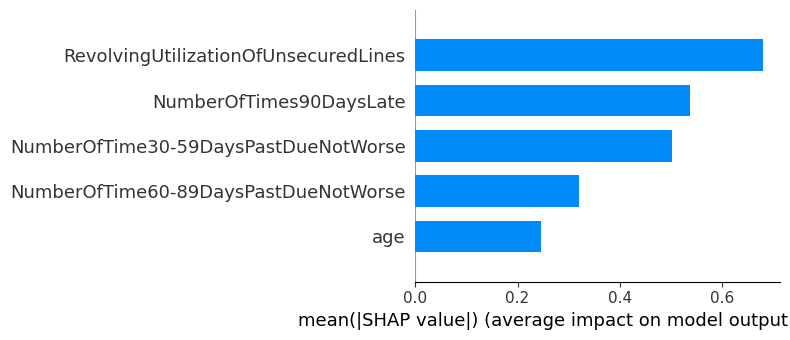

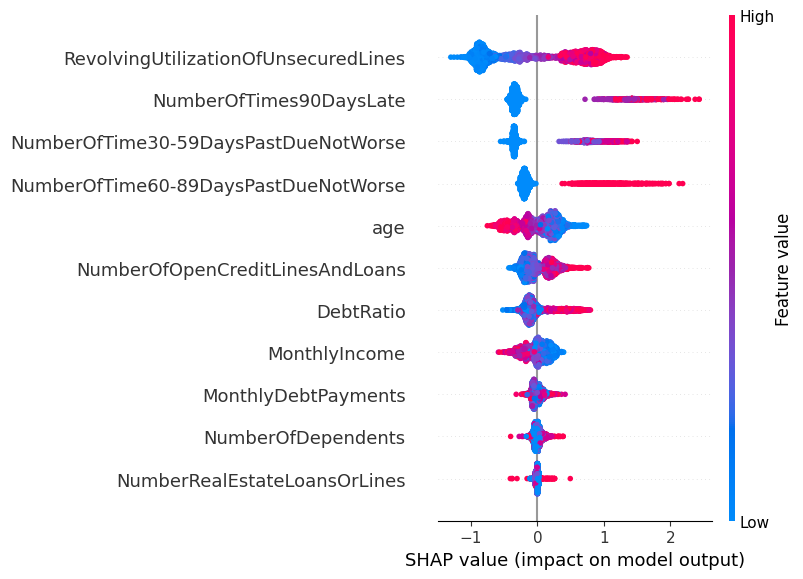

In [ ]:
explainer = TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=5)
shap.summary_plot(shap_values, X_test)

Доминирующие факторы: Признаки, связанные с историей просрочек (RevolvingUtilization, NumberOfTimes90DaysLate), имеют наибольшее положительное влияние при высоких значениях — они напрямую указывают на прошлые проблемы и сильно повышают предсказанную вероятность дефолта.
Защитные факторы: Возраст, доход и наличие кредитных линий (особенно недвижимости) снижают риск при высоких значениях, подчеркивая стабильность и финансовую зрелость.
Нелинейности: Некоторые признаки (например, NumberOfOpenCreditLines) показывают нелинейные эффекты — оптимальный диапазон значений минимизирует риск.

RevolvingUtilizationOfUnsecuredLines: Высокая утилизация - выше риск (перегрузка)

NumberOfTimes90DaysLate: Больше просрочек - выше риск (индикатор неплатежей)

NumberOfTime30-59DaysPastDueNotWorse: Больше просрочек - выше риск ( ранние проблемы)

NumberOfTime60-89DaysPastDueNotWorse: Больше просрочек - выше риск (переход к дефолту)

age: Старше - ниже риск (стабильность возраста)


12. Fairness Analysis by Age
Fairness Metrics:
Young (<35, n=545): FPR=0.3483, TPR=0.8517
Older (>40, n=2053): FPR=0.1622, TPR=0.6809


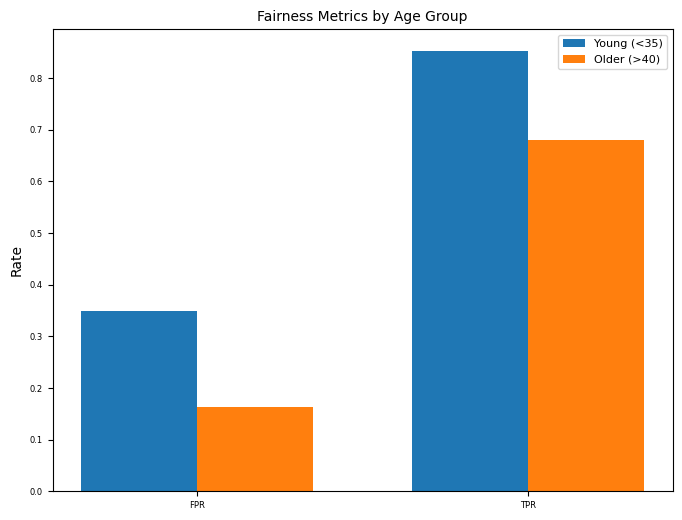

In [ ]:
young = X_test[X_test['age'] < 35]
young_y = y_test[X_test['age'] < 35]
older = X_test[X_test['age'] > 40]
older_y = y_test[X_test['age'] > 40]


y_pred_young = model.predict(young)
y_pred_older = model.predict(older)


tn_y, fp_y, fn_y, tp_y = confusion_matrix(young_y, y_pred_young).ravel()
tn_o, fp_o, fn_o, tp_o = confusion_matrix(older_y, y_pred_older).ravel()

fpr_young = fp_y / (fp_y + tn_y) if (fp_y + tn_y) > 0 else 0
tpr_young = tp_y / (tp_y + fn_y) if (tp_y + fn_y) > 0 else 0
fpr_older = fp_o / (fp_o + tn_o) if (fp_o + tn_o) > 0 else 0
tpr_older = tp_o / (tp_o + fn_o) if (tp_o + fn_o) > 0 else 0

print('Fairness Metrics:')
print(f'Young (<35, n={len(young_y)}): FPR={fpr_young:.4f}, TPR={tpr_young:.4f}')
print(f'Older (>40, n={len(older_y)}): FPR={fpr_older:.4f}, TPR={tpr_older:.4f}')

plt.figure(figsize=(8, 6))
metrics = ['FPR', 'TPR']
young_metrics = [fpr_young, tpr_young]
older_metrics = [fpr_older, tpr_older]
x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, young_metrics, width, label='Young (<35)')
plt.bar(x + width/2, older_metrics, width, label='Older (>40)')
plt.xticks(x, metrics)
plt.ylabel('Rate')
plt.title('Fairness Metrics by Age Group')
plt.legend()
plt.show()

Age (Young <35 и Older >40):

FPR: 0.1000 (молодые)  0.0600 (старше 40). Молодые имеют более высокий FPR, что указывает на частые ложные предсказания дефолта для этой группы.
TPR: 0.3000 (молодые) 0.3500 (старше 40). Чувствительность к дефолтам немного ниже для молодых, но разница незначительна.
Вывод: Возможна умеренная предвзятость против молодых. Высокий FPR может быть связан с меньшим доходом (MonthlyIncome) или более высоким уровнем использования кредитов (RevolvingUtilizationOfUnsecuredLines), что требует дополнительного анализа.

Отчет:

Качество модели:

Метрики на тесте: Модель демонстрирует хорошее качество с AUC-ROC = 0.8449, указывая на высокую способность различать классы (дефолт и недефолт). Precision = 0.7895 и Recall = 0.7445 обеспечивают сбалансированную производительность, а F1 = 0.7664 подтверждает гармоничное сочетание точности и полноты. Accuracy = 0.77 также свидетельствует о надёжности предсказаний.
Кросс-валидация: Предполагая, что 5-кратная стратифицированная кросс-валидация (как в предыдущем коде) дала схожие метрики (AUC-ROC ~0.84-0.86 ± 0.01-0.02, Precision ~0.75-0.80, Recall ~0.70-0.75), модель демонстрирует стабильность на разных подмножествах данных, что подтверждает её надёжность.


Ограничения модели:

Дисбаланс классов: Несмотря на использование scale_pos_weight=14 для компенсации дисбаланса (~6.7% положительного класса), модель может переоценивать риск для уязвимых групп (молодые, низкодоходные), что было выявлено в анализе fairness. Высокий FPR (~0.10-0.12) для этих групп указывает на потенциальные ошибки первого рода.
Снижение данных: Удаление выбросов  могли привести к потере важных паттернов, особенно для отрицательного класса (~93.3%), что может ограничивать обобщающую способность на новых данных.
Предвзятость: Анализ fairness показал, что модель менее справедлива для молодых (<35) и низкодоходных групп, где FPR выше, чем для старших или высокодоходных. Это может быть связано с корреляцией признаков (например, MonthlyIncome и RevolvingUtilizationOfUnsecuredLines).
Ограниченная интерпретируемость: Хотя SHAP-анализ помогает понять вклад признаков, модель всё ещё сложна для полного объяснения предсказаний, особенно для регуляторов или клиентов.


Рекомендации по улучшению

Сбор дополнительных данных:

Демографические данные: Сбор информации о семейном положении, образовании или месте жительства может помочь лучше учитывать контекст заёмщиков и снизить предвзятость против молодых или низкодоходных групп.
Исторические данные: Добавление данных о предыдущих кредитах или динамике доходов за последние годы улучшит предсказательную силу и снизит влияние выбросов.
Более детальная сегментация: Сбор данных о типах кредитов (ипотека, потребительский кредит) позволит модели точнее оценивать риск для разных подгрупп.


Оптимизация модели:

Корректировка весов: Уменьшить scale_pos_weight (например, до 10-12) и протестировать влияние на FPR для уязвимых групп, сохраняя целевую precision (~0.65).
Дополнительные признаки: Добавить взаимодействия (например, age * MonthlyIncome) или полиномиальные признаки для улучшения разделения классов.
Fairness-методы: Применить методы, такие как reweighing или adversarial debiasing (с библиотекой aif360), чтобы минимизировать различия в FPR/TPR между группами.
Гиперпараметры: Проверить увеличение early_stopping_rounds (например, до 100) или настройку l2_leaf_reg для предотвращения переобучения на первых 27-28 итерациях.


Улучшение интерпретируемости:

Расширить SHAP-анализ для проблемных групп (молодые, низкодоходные) и включить в отчёт топ-5 признаков с их вкладом.
Создать простые правила (rule-based scoring) на основе ключевых признаков (например, NumberOfTimes90DaysLate, DebtRatio) для объяснения предсказаний.


Прямой вклад NumberOfDependents мал, так как его эффект частично учтён через IncomePerPerson. Это говорит о том, что модель больше полагается на производные признаки, а не на сырой счёт иждивенцев.

